<span style="color:blue; font-style:italic; font-size:30px;"># Sets Up</span>

In [20]:
import os
import glob, cv2, numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf

In [2]:
import tensorflow_datasets as tfds

In [3]:
from sklearn.decomposition import PCA

### 1. Apply PCA to the images. How many components do you need to preserve 95% of the variance? [3 points]

In [4]:
# Load the dataset (as_supervised=True yields (image, label) pairs)
ds = tfds.load("horses_or_humans", split="train", as_supervised=True)

# Flatten every image and collect them into the X matrix
images = []
for img, _ in ds:
    arr = img.numpy().astype("float32")  
    images.append(arr.reshape(-1))        
X = np.stack(images)                     

# Fit PCA to retain 95% of the variance
pca = PCA(n_components=0.95, svd_solver='full')
pca.fit(X)

# Print out how many components are needed
print("Number of components needed to preserve 95% variance:", pca.n_components_)

Number of components needed to preserve 95% variance: 296


### 2. Plot 10 images of your choice in the original form (without PCA) and then plot their reconstruction (projection in the original space) after you kept 90% of variance using PCA. [3 points] 

In [5]:
# Fit PCA for 90% variance ———
pca90 = PCA(n_components=0.90, svd_solver='full')
X_proj = pca90.fit_transform(X)                # shape (n_samples, K)
X_rec  = pca90.inverse_transform(X_proj)       # shape (n_samples, D)

# Pick 10 random samples ———
np.random.seed(0)
idx = np.random.choice(len(X), size=10, replace=False)

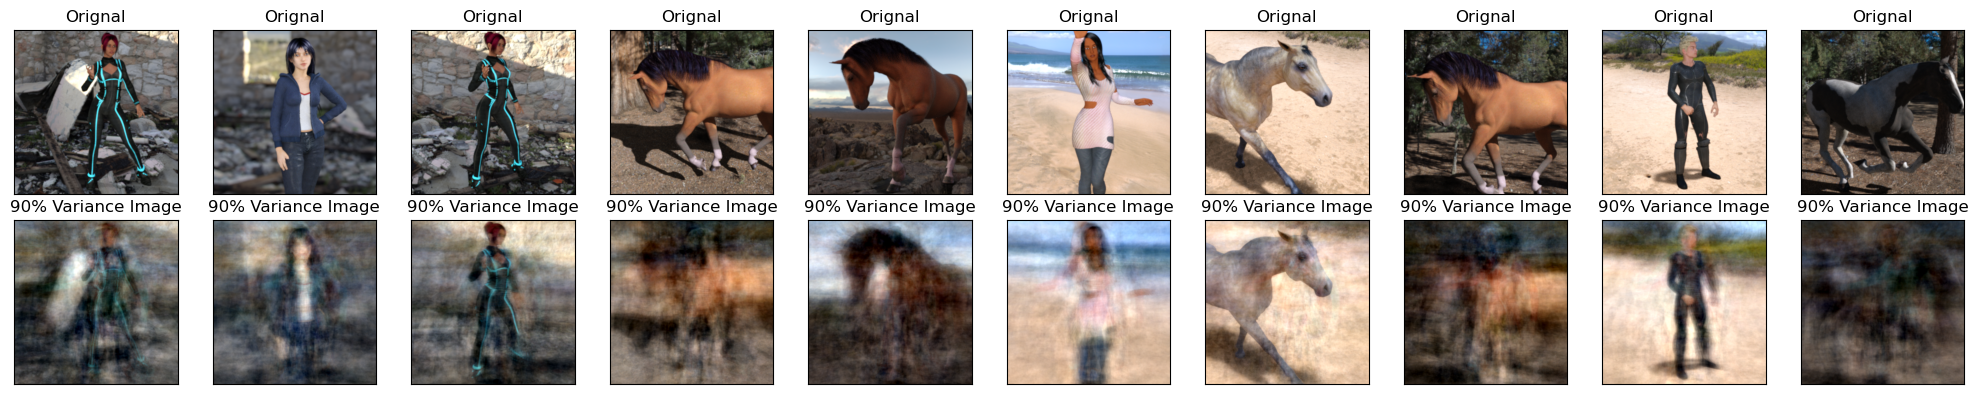

In [6]:
# Plot 
fig, axes = plt.subplots(2, 10, figsize=(20, 4),
                         subplot_kw={'xticks':[], 'yticks':[]})
for i, j in enumerate(idx):
    orig = X[j].reshape(img.shape)      # (H, W, C)
    rec  = X_rec[j].reshape(img.shape)
    axes[0, i].imshow(orig.astype('uint8'))
    axes[0, i].set_title("Orignal")
    axes[1, i].imshow(np.clip(rec, 0, 255).astype('uint8'))
    axes[1, i].set_title("90% Variance Image")
plt.tight_layout()
plt.show()

### 3. Each of the images belongs to one of humans or horses categories. We will now try to see if the visualization can help us identify different clusters.

A. Use PCA to reduce dimensionality to only 2 dimensions. How much of the variance is explained with the first two principal components? [2 points].

In [7]:
pca2 = PCA(n_components=2, svd_solver='full')
pca2.fit(X)

explained = pca2.explained_variance_ratio_
print(f"Variance explained by PC1: {explained[0]*100:.1f}%")
print(f"Variance explained by PC2: {explained[1]*100:.1f}%")
print(f"Total for first two PCs: {(explained.sum())*100:.1f}%")


Variance explained by PC1: 40.6%
Variance explained by PC2: 8.7%
Total for first two PCs: 49.3%


B. Plot a 2D scatter plot of the images spanned by the first two principal components. Each image will be represented with a dot. Make the color of the dot correspond to the image category (so you will have two different colors). Then add some humans/horses images to the visualization to better understand what features in the images are accounting for the majority of variance in the data (your visualization should look similar to the one after line 71 in this file https://github.com/ageron/handson-ml3/blob/main/08_dimensionality_reduction.ipynbLinks to an external site. but with images of humans/horses instead of MNIST digits). Repeat the process and create the same type of plots for t-SNE, LLE and UMAP. [6 points]

In [8]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, LocallyLinearEmbedding
import umap

In [9]:
# Load "horses_or_humans" dataset
ds = tfds.load("horses_or_humans", split="train", as_supervised=True)

images = []
labels = []
for img, lbl in ds:
    images.append(img.numpy().astype("uint8"))       
    labels.append(lbl.numpy())                       # 0=horse, 1=human
X = np.stack([im.reshape(-1) for im in images])      
y = np.array(labels)

# Prepare color mapping
color_map = {0: "tab:blue", 1: "tab:orange"}
colors = [color_map[int(lbl)] for lbl in y]

# 1) PCA
pca = PCA(n_components=2, svd_solver="full")
X_pca = pca.fit_transform(X)  

# 2) t‑SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# 3) LLE
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=30)
X_lle = lle.fit_transform(X)

# 4) UMAP
umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X)


In [10]:
def scatter_plot_with_images(embedding, images, labels, title, indices_to_annotate, zoom=0.07):
    """
    embedding: array-like of shape (n_samples, 2)
    images: list/array of images in HxWxC format
    labels: list/array of integer labels (0/1)
    title: string for the plot title
    indices_to_annotate: list of sample indices to overlay images
    zoom: float scaling factor for the thumbnails
    """
    # Define color mapping – adjust if you have more classes
    color_map = {0: "tab:blue", 1: "tab:orange"}
    colors = [color_map[int(lbl)] for lbl in labels]

    plt.figure(figsize=(6, 6))
    # scatter all points
    plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=5, alpha=0.6)
    ax = plt.gca()
    # overlay selected image thumbnails
    for idx in indices_to_annotate:
        img = images[idx]
        ab = AnnotationBbox(
            OffsetImage(img, zoom=zoom),
            (embedding[idx, 0], embedding[idx, 1]),
            frameon=False
        )
        ax.add_artist(ab)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
# Due to the large number of images, we only show 100 images.
indices_to_annotate = list(range(0, len(X), 10))

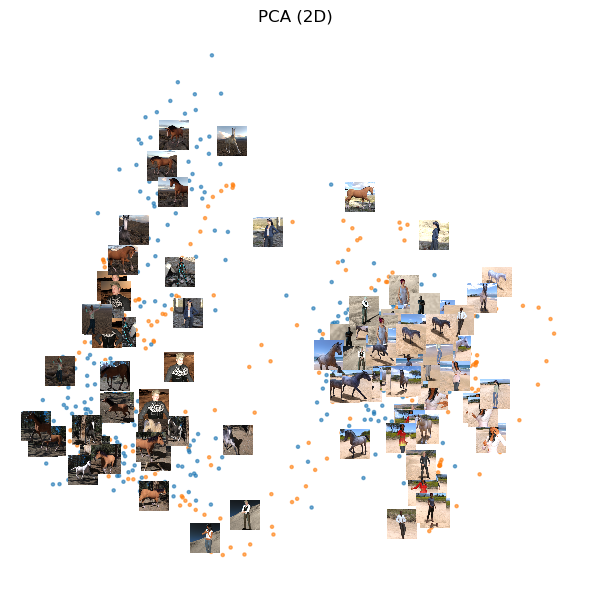

In [11]:
# PCA Visualization
scatter_plot_with_images(X_pca, images, labels, "PCA (2D)", indices_to_annotate)

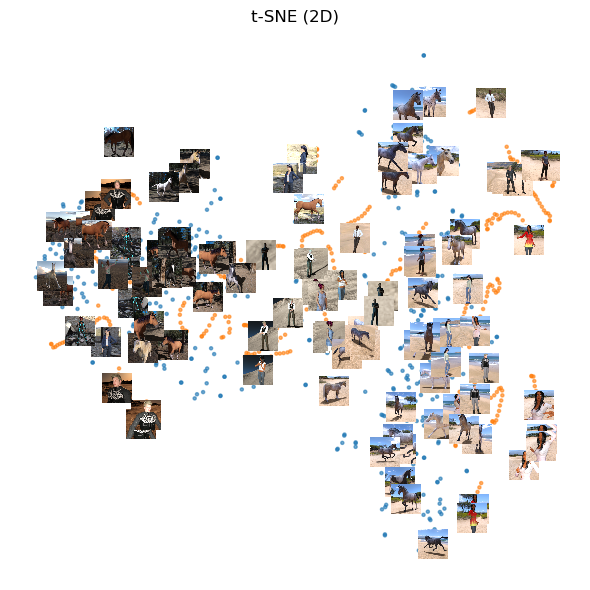

In [12]:
# t-SNE Visualization
scatter_plot_with_images(X_tsne, images, labels, "t-SNE (2D)", indices_to_annotate)

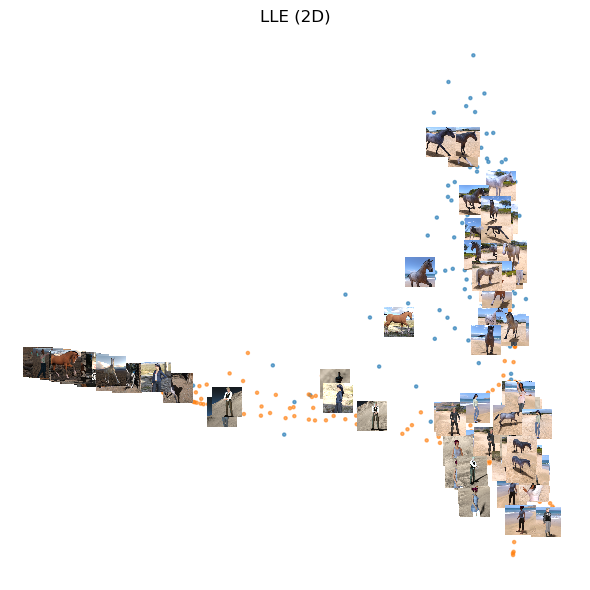

In [13]:
# LLE Visualization
scatter_plot_with_images(X_lle, images, labels, "LLE (2D)", indices_to_annotate)

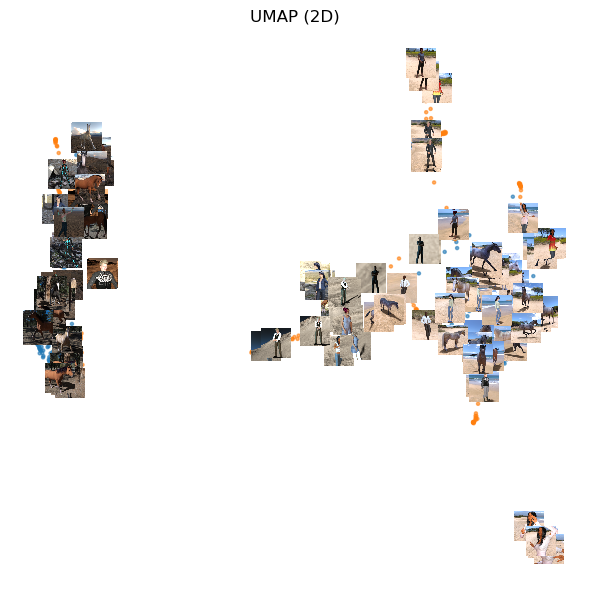

In [14]:
# UMAP Visualization
scatter_plot_with_images(X_umap, images, labels, "UMAP (2D)", indices_to_annotate)

C. Discuss your observations. [1 point]

**PCA (a linear method) only cares about directions of largest variance**  
- The first principal component usually captures “overall brightness” or “contrast” across the whole image, simply because that’s where the pixel‐value variance is greatest.  
- The second principal component often corresponds to another global effect like different lighting or background darkness.  
- As a result, in the PCA scatter plot the points are split by “bright vs. dark” (or “light vs. shadowy” scenes) first—horses and humans do not form separate clusters.

**t‑SNE and UMAP (nonlinear embeddings) excel at preserving local similarity**  
- They tend to group together images that are “close” in high‑dimensional space (similar textures, shapes, or pixel patterns).  
- In their 2D plots you can see horses roughly clustering together and humans clustering together (even if there’s some overlap), because these methods focus on local neighborhoods rather than global variance.

**LLE (Locally Linear Embedding) sits in between**  
- LLE also tries to preserve each point’s local neighborhood but through a linear mapping.  
- In the LLE plot you’ll see some clusters of similarly posed horses, but the separation between horses and humans is less distinct than with UMAP.

### 4. Cluster the images using K-Means.

A. You can reduce the dimensionality using PCA if you wish, but keep at least 95% of the variance. Determine the number of clusters using one of the techniques we discussed in class. [4 points]

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [16]:
# PCA keep 99% of variance
pca = PCA(n_components=0.99, svd_solver="full")
X_reduced = pca.fit_transform(X)

# ----> replace the old print with these:
print("Reduced data shape:", X_reduced.shape)
print("Number of principal components:", pca.n_components_)

# Silhouette analysis to pick k
sil_scores = []
K_range = range(2, 10)
for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_reduced)
    sil    = silhouette_score(X_reduced, labels)
    sil_scores.append(sil)

best_k = K_range[np.argmax(sil_scores)]
print("Optimal number of clusters according to silhouette score:", best_k)


Reduced data shape: (1027, 681)
Number of principal components: 681
Optimal number of clusters according to silhouette score: 2


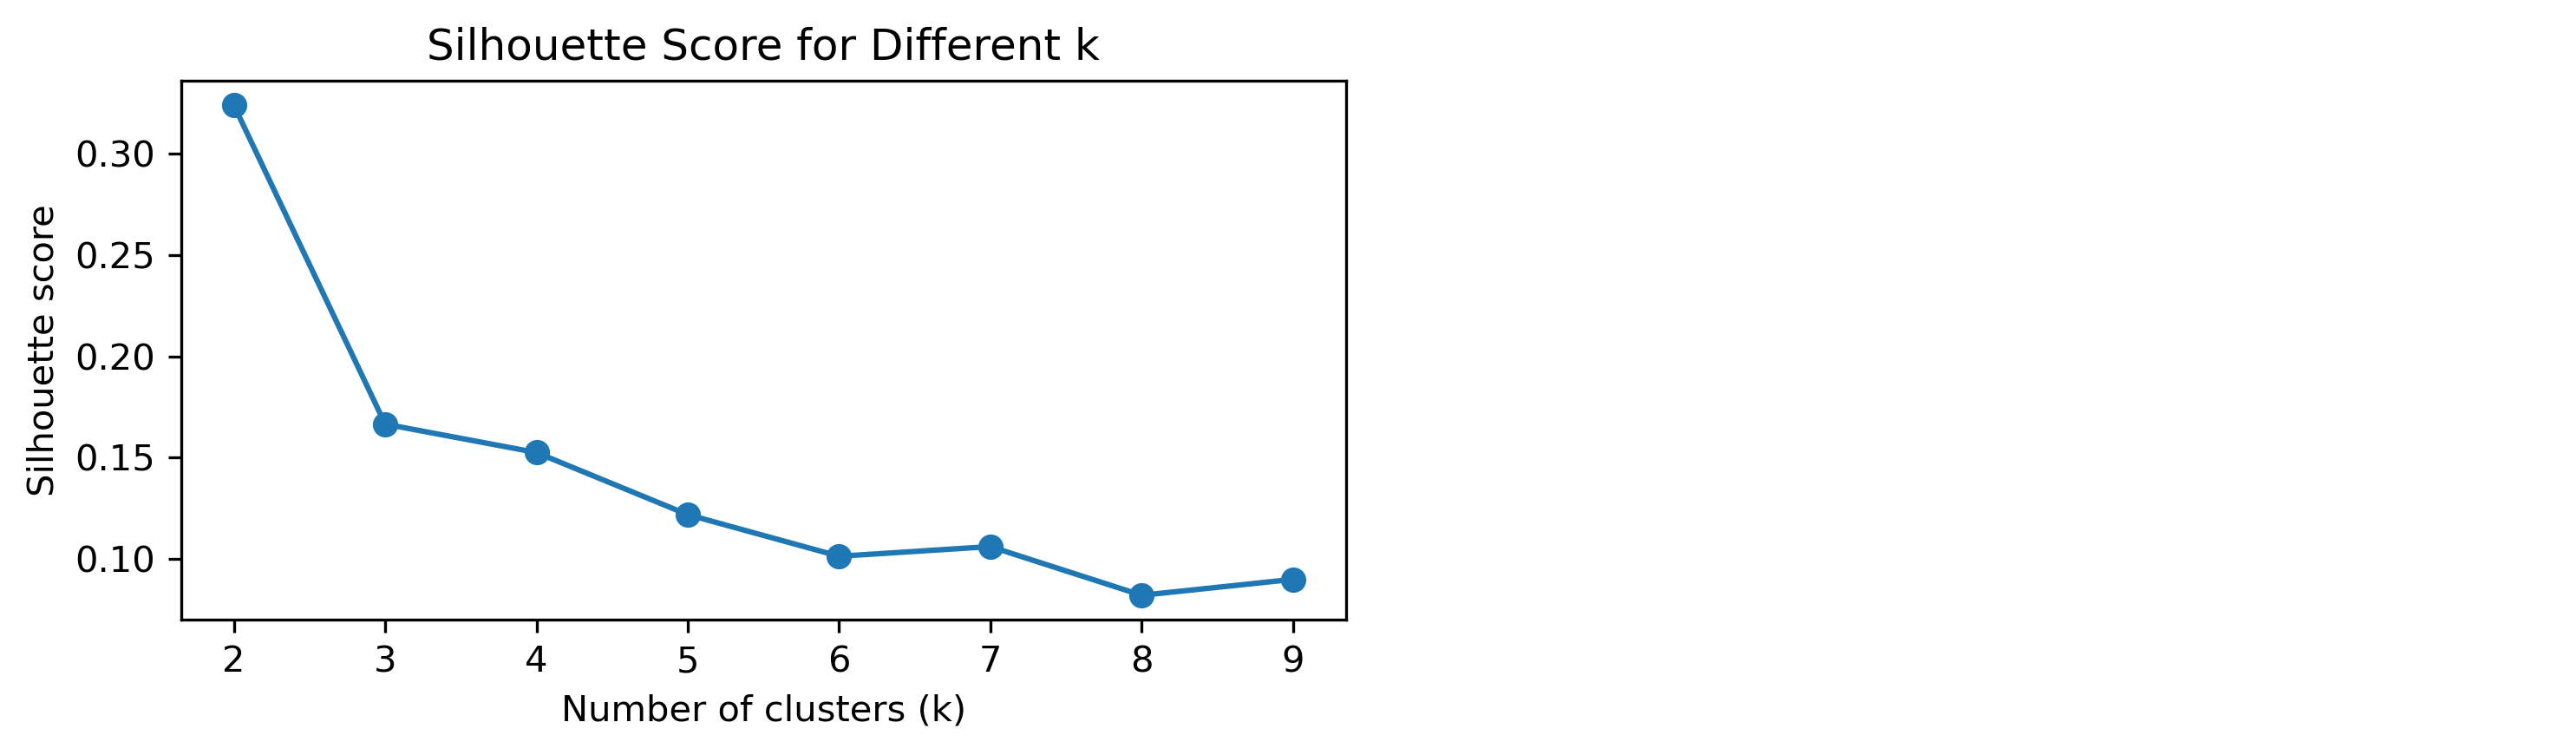

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), dpi=300)

# Silhouette scores vs. number of clusters (k)
axes[0].plot(list(K_range), sil_scores, marker='o')
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Silhouette score")
axes[0].set_title("Silhouette Score for Different k")
axes[1].axis("off")
plt.tight_layout()
plt.show()

B. Set the number of clusters to 2, report clustering accuracy and show a confusion matrix. [4 points]

In [18]:
from sklearn.metrics          import confusion_matrix, accuracy_score
from scipy.optimize           import linear_sum_assignment

In [23]:
# Run K‑Means with k=2
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X_reduced)

# We maximize trace(cm) via Hungarian on the negative matrix
cm_raw = confusion_matrix(y, cluster_labels)
row_ind, col_ind = linear_sum_assignment(-cm_raw)
mapping = {col: row for row, col in zip(row_ind, col_ind)}

# Remap cluster labels to match true labels
cluster_mapped = np.array([mapping[cl] for cl in cluster_labels])

# Compute accuracy & “aligned” confusion matrix
acc       = accuracy_score(y, cluster_mapped)
cm_aligned = confusion_matrix(y, cluster_mapped)

print(f"Clustering accuracy: {acc:.2%}")
print("Aligned confusion matrix:")
print(cm_aligned)

Clustering accuracy: 55.99%
Aligned confusion matrix:
[[221 279]
 [173 354]]


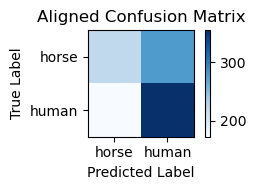

In [24]:
label_names = ["horse", "human"]

plt.figure(figsize=(3, 2),)
plt.imshow(cm_aligned, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Aligned Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names)
plt.yticks(tick_marks, label_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

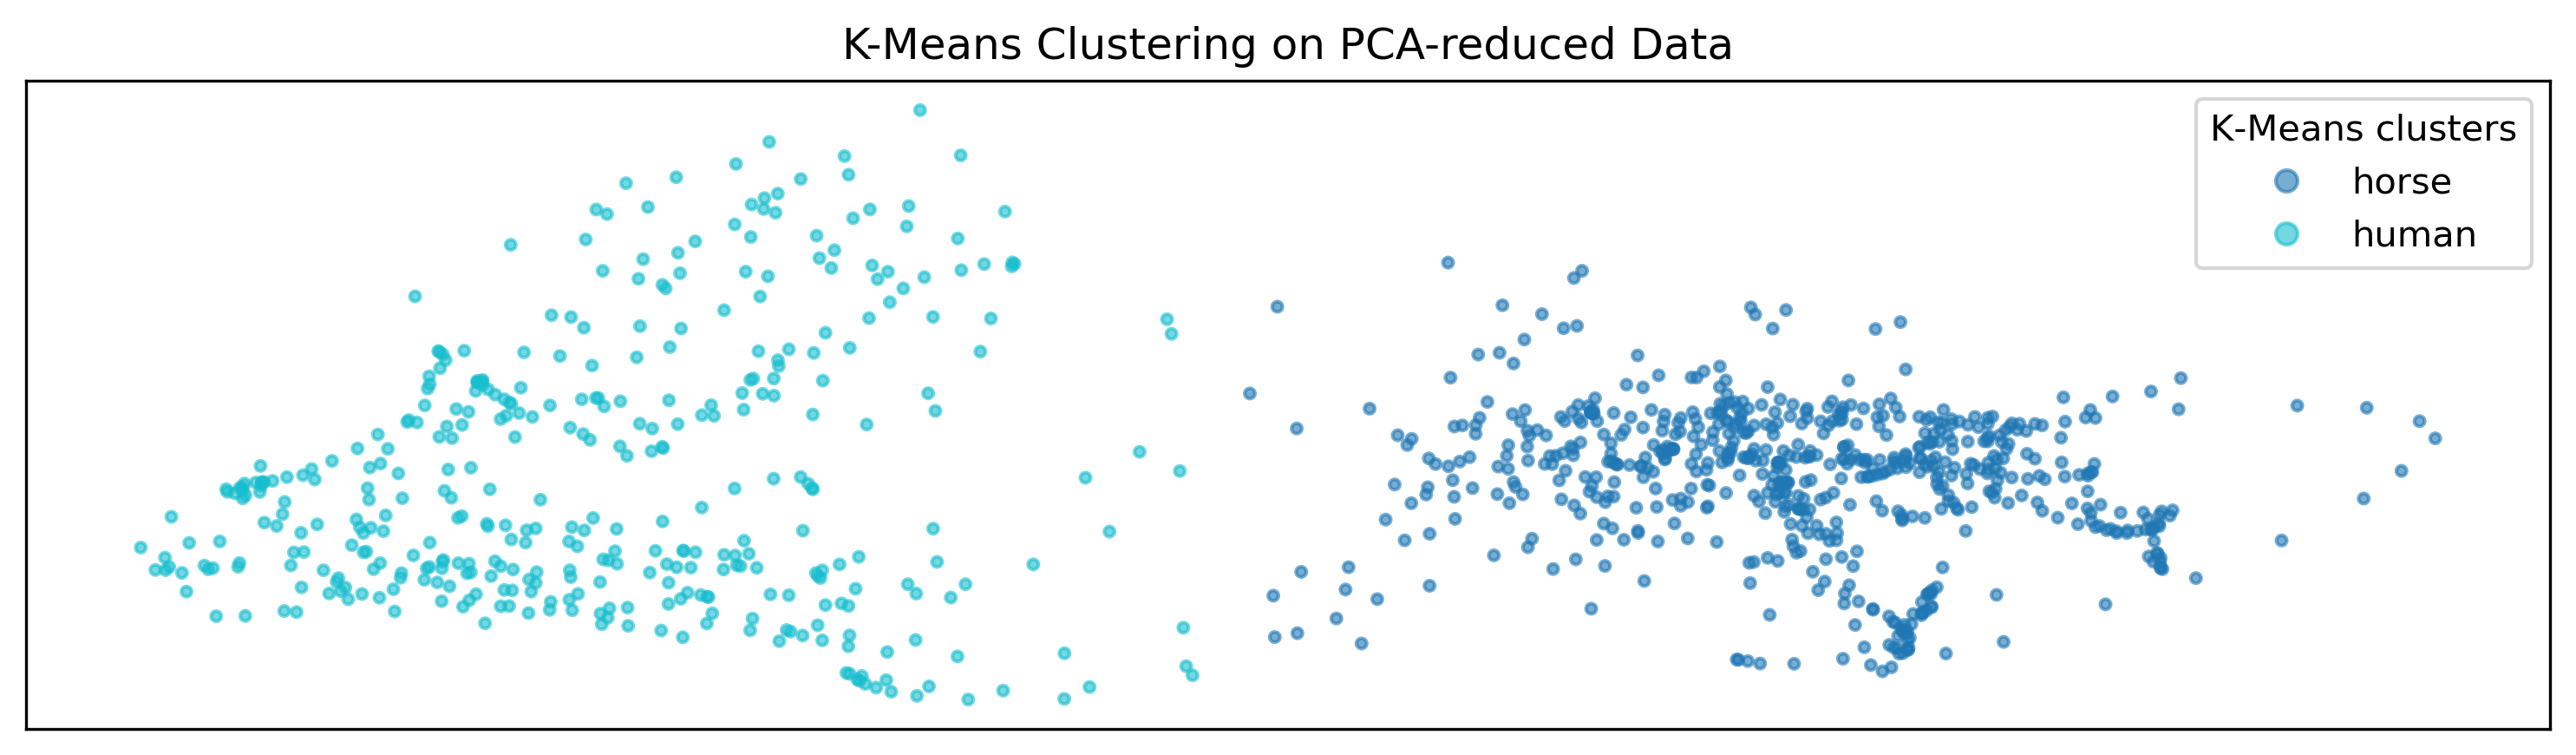

In [25]:
fig, ax = plt.subplots(figsize=(10, 3), dpi=300)

cluster_names = ["horse", "human"]   # index 0 == horse, index 1 == human

scatter = ax.scatter(
    X_pca[:,0], X_pca[:,1],
    c=cluster_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)
handles = scatter.legend_elements()[0]
ax.legend(handles, cluster_names, title="K‑Means clusters")

ax.set_title("K-Means Clustering on PCA-reduced Data")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


### 5. Cluster the images using EM.

A. You can again reduce the dimensionality using PCA if you wish, but keep at least 95% of the variance. Determine the number of clusters using one of the techniques we discussed in class. [4 points]

In [26]:
from sklearn.mixture          import GaussianMixture

In [27]:
# PCA keep 99% of variance
pca = PCA(n_components=0.99, svd_solver="full")
X_reduced = pca.fit_transform(X)
print("Reduced data shape:", X_reduced.shape)
print("Number of principal components:", pca.n_components_)

# Use BIC (Bayesian Information Criterion) to pick n_components for GMM
bic_scores = []
K_range   = range(1, 10)  
for k in K_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_reduced)
    bic_scores.append(gmm.bic(X_reduced))
    print(f"k={k:2d} → BIC = {bic_scores[-1]:.0f}")

# Pick the k with the lowest BIC
best_k = K_range[np.argmin(bic_scores)]
print("Optimal number of clusters by BIC:", best_k)

Reduced data shape: (1027, 681)
Number of principal components: 681
k= 1 → BIC = 12420161
k= 2 → BIC = 9707513
k= 3 → BIC = 6328833
k= 4 → BIC = 6139548
k= 5 → BIC = 6734676
k= 6 → BIC = 7195145
k= 7 → BIC = 8216939
k= 8 → BIC = 8549975
k= 9 → BIC = 10313099
Optimal number of clusters by BIC: 4


Optimal number of clusters according to BIC: 4


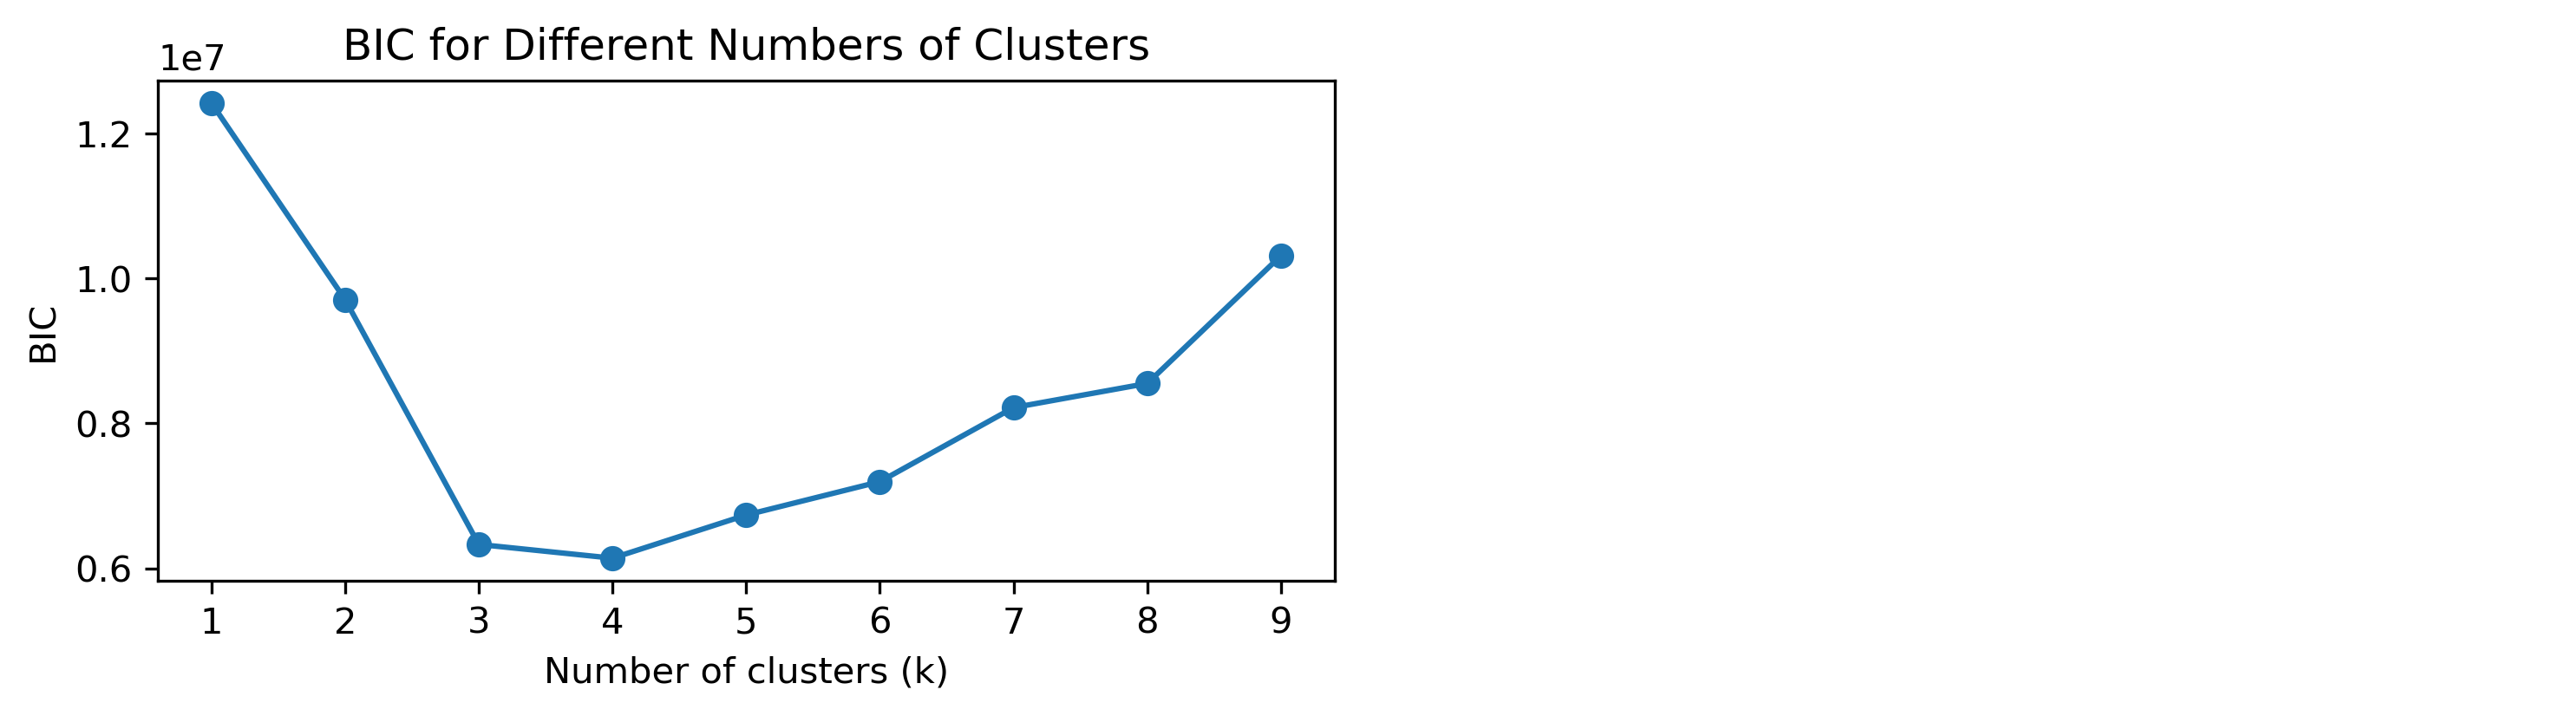

In [28]:
optimal_k = K_range[np.argmin(bic_scores)]
print("Optimal number of clusters according to BIC:", optimal_k)

fig, axes = plt.subplots(1, 2, figsize=(10, 3), dpi=300)

# BIC vs. number of clusters (k)
axes[0].plot(list(K_range), bic_scores, marker='o')
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("BIC")
axes[0].set_title("BIC for Different Numbers of Clusters")
axes[1].axis("off")
plt.tight_layout()
plt.show()

B. Set the number of clusters to 2, report clustering accuracy and show a confusion matrix. [4 points]

In [29]:
# Fit GMM with 2 components
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_reduced)
gmm_labels = gmm.predict(X_reduced)

# Compute raw confusion matrix
cm_raw = confusion_matrix(y, gmm_labels)

# Align cluster IDs → true labels via Hungarian algorithm
row_ind, col_ind = linear_sum_assignment(-cm_raw)
mapping = {col: row for row, col in zip(row_ind, col_ind)}
gmm_mapped = np.array([mapping[lab] for lab in gmm_labels])

# Compute accuracy & aligned confusion matrix
acc        = accuracy_score(y, gmm_mapped)
cm_aligned = confusion_matrix(y, gmm_mapped)

print(f"GMM clustering accuracy: {acc:.2%}")
print("Aligned confusion matrix:")
print(cm_aligned)

GMM clustering accuracy: 55.99%
Aligned confusion matrix:
[[221 279]
 [173 354]]


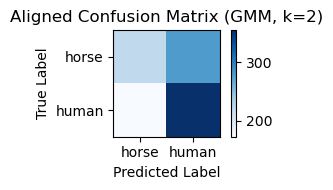

In [30]:
# Plot only the aligned confusion matrix
label_names = ["horse", "human"]
plt.figure(figsize=(3, 2),)
plt.imshow(cm_aligned, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Aligned Confusion Matrix (GMM, k=2)")
plt.colorbar()

tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names)
plt.yticks(tick_marks, label_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

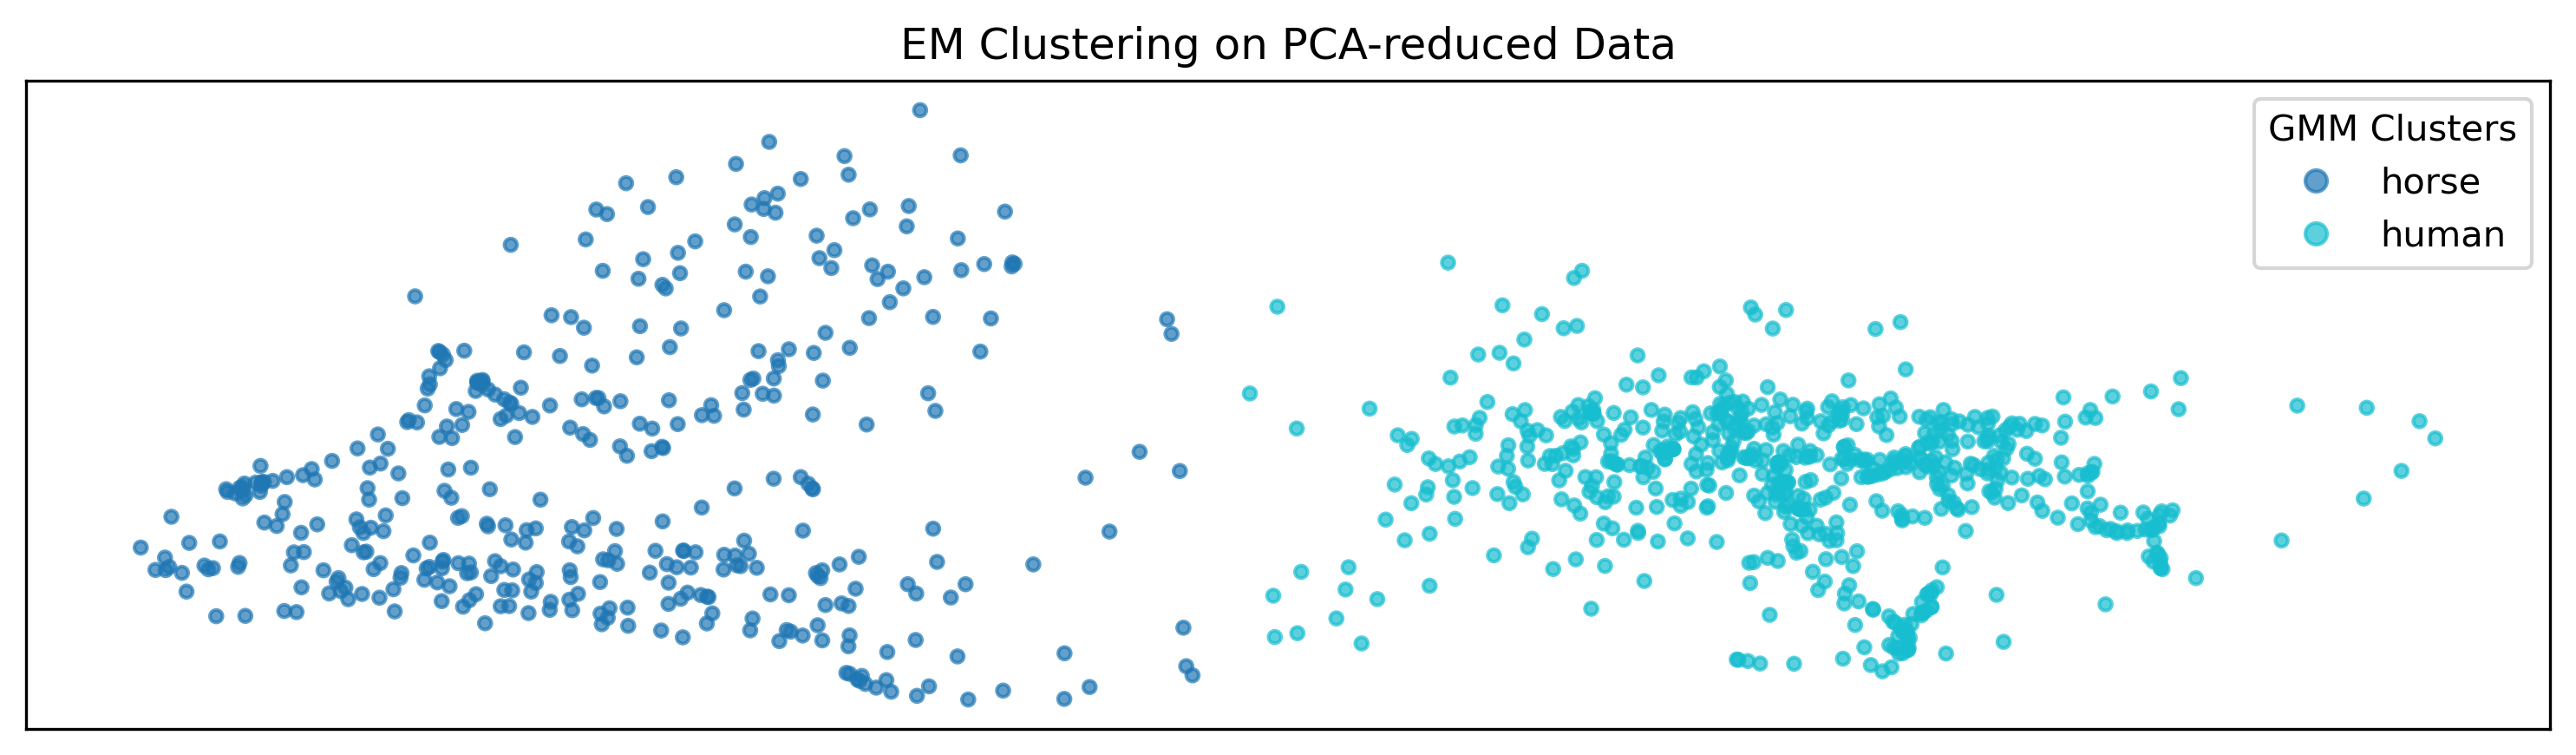

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3), dpi=300)

# scatter all points, coloring by GMM (EM) cluster assignment
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=gmm_mapped,                # EM-based labels
    cmap="tab10",
    s=12,
    alpha=0.7
)

# legend: map each cluster color → class name
handles = scatter.legend_elements()[0]
ax.legend(handles, cluster_names, title="GMM Clusters")

ax.set_title("EM Clustering on PCA-reduced Data")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


D. Use the model to generate 20 new rocks (using the sample() method), and visualize them in the original image space (since you used PCA, you will need to use its inverse_transform() method). [4 points]

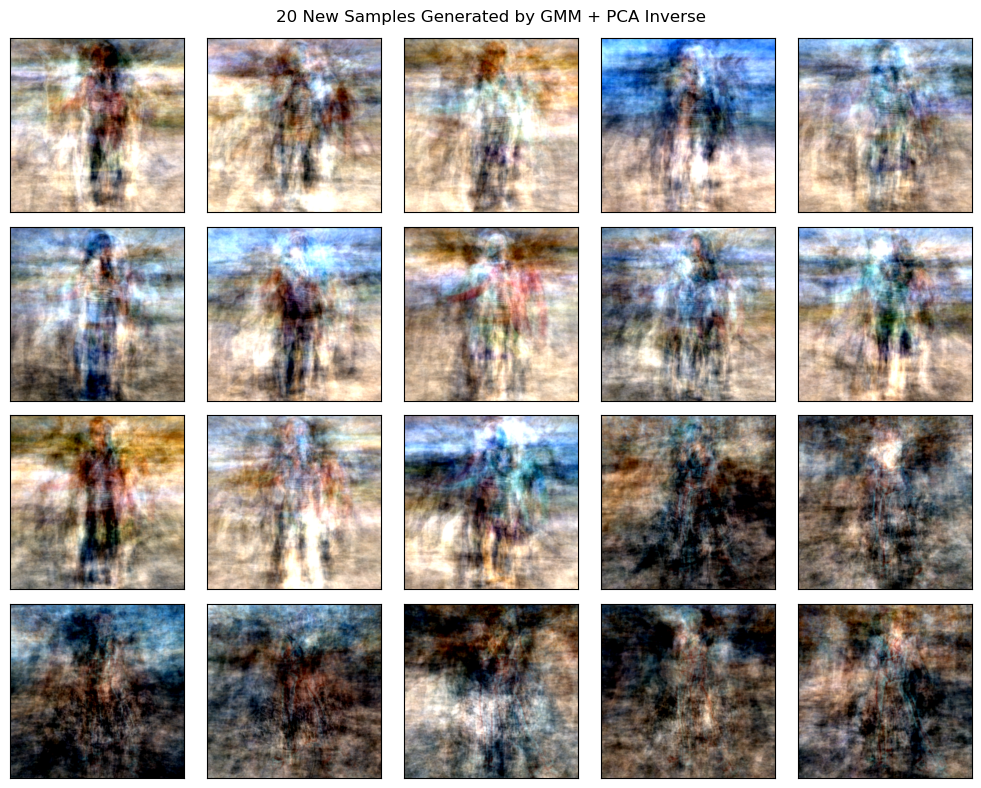

In [32]:
# Sample 20 points from the GMM in the PCA‐reduced space
X_new_reduced, comp_idxs = gmm.sample(20)  

# Project them back to the original high‐dimensional space
X_new_flat = pca.inverse_transform(X_new_reduced)  

# Reshape into images and clip to valid uint8 range
H = W = int(np.sqrt(X_new_flat.shape[1] // 3))
C = 3
new_images = X_new_flat.reshape(-1, H, W, C)
new_images = np.clip(new_images, 0, 255).astype("uint8")

# Plot the 20 samples
fig, axes = plt.subplots(4, 5, figsize=(10, 8), dpi=100,
                         subplot_kw={"xticks":[], "yticks":[]})
for ax, img in zip(axes.flat, new_images):
    ax.imshow(img)
plt.suptitle("20 New Samples Generated by GMM + PCA Inverse")
plt.tight_layout()
plt.show()


### 6. Build a feed‑forward neural network with a small number of hidden layers (using dense layers and/or CNN layers). We recommend using TensorFlow’s Keras or PyTorch. Your task is to classify the images into two classes (horses vs. humans). Use 75% of the images for training and 25% for validation. Choose a number of neurons that you find appropriate and efficient so that training runs in a reasonable time. Hidden layers should use the ReLU activation function. Train the network for multiple epochs until it converges—if training is too slow, adjust the learning rate or simplify the network. We won’t penalize you for an overly simple architecture, but we expect performance well above random chance—in other words, both training and validation losses should decrease and accuracies should increase over epochs. We suggest using Colab (the free tier is fine), and be sure to enable a GPU to speed up training (in Colab, go to Edit → Notebook settings → Hardware accelerator → GPU).

A. Report the training time (use code to do this). [1 point]

In [33]:
import os, time, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import tensorflow_datasets as tfds

# Reproducibility
tf.random.set_seed(0)
np.random.seed(0)

# Hyperparameters
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
EPOCHS      = 20

# Load & preprocess the dataset
ds_all = tfds.load("horses_or_humans", split="train", as_supervised=True)

def preprocess(img, label):
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

ds = ds_all.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Collect into NumPy for train/val split
images, labels = [], []
for img, lbl in ds:
    images.append(img.numpy())
    labels.append(lbl.numpy())
X = np.stack(images)
y = np.array(labels)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

# Build tf.data pipelines
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Define a small CNN
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = layers.Conv2D(32, 3, activation='relu', name='conv2d')(inputs)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(64, 3, activation='relu', name='conv2d_1')(x)
x = layers.MaxPool2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu', name='dense_mid')(x)
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

# 5) Train and measure time
start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)
print(f"\nTraining time: {time.time() - start_time:.1f} seconds")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_mid (Dense)               │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.5532 - loss: 0.8542 - val_accuracy: 0.7393 - val_loss: 0.6181
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.9338 - loss: 0.1790 - val_accuracy: 0.9572 - val_loss: 0.1229
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.9866 - loss: 0.0426 - val_accuracy: 0.9650 - val_loss: 0.0781
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.9797 - loss: 0.0597 - val_accuracy: 0.9767 - val_loss: 0.0633
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.9904 - loss: 0.0238 - val_accuracy: 0.9728 - val_loss: 0.0489
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.9990 - loss: 0.0089 - val_accuracy: 0.9728 - val_loss: 0.0329
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9883 - val_loss: 0.0308
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.

B. Plot training and validation loss and accuracy as a function of training epochs. [2 points]

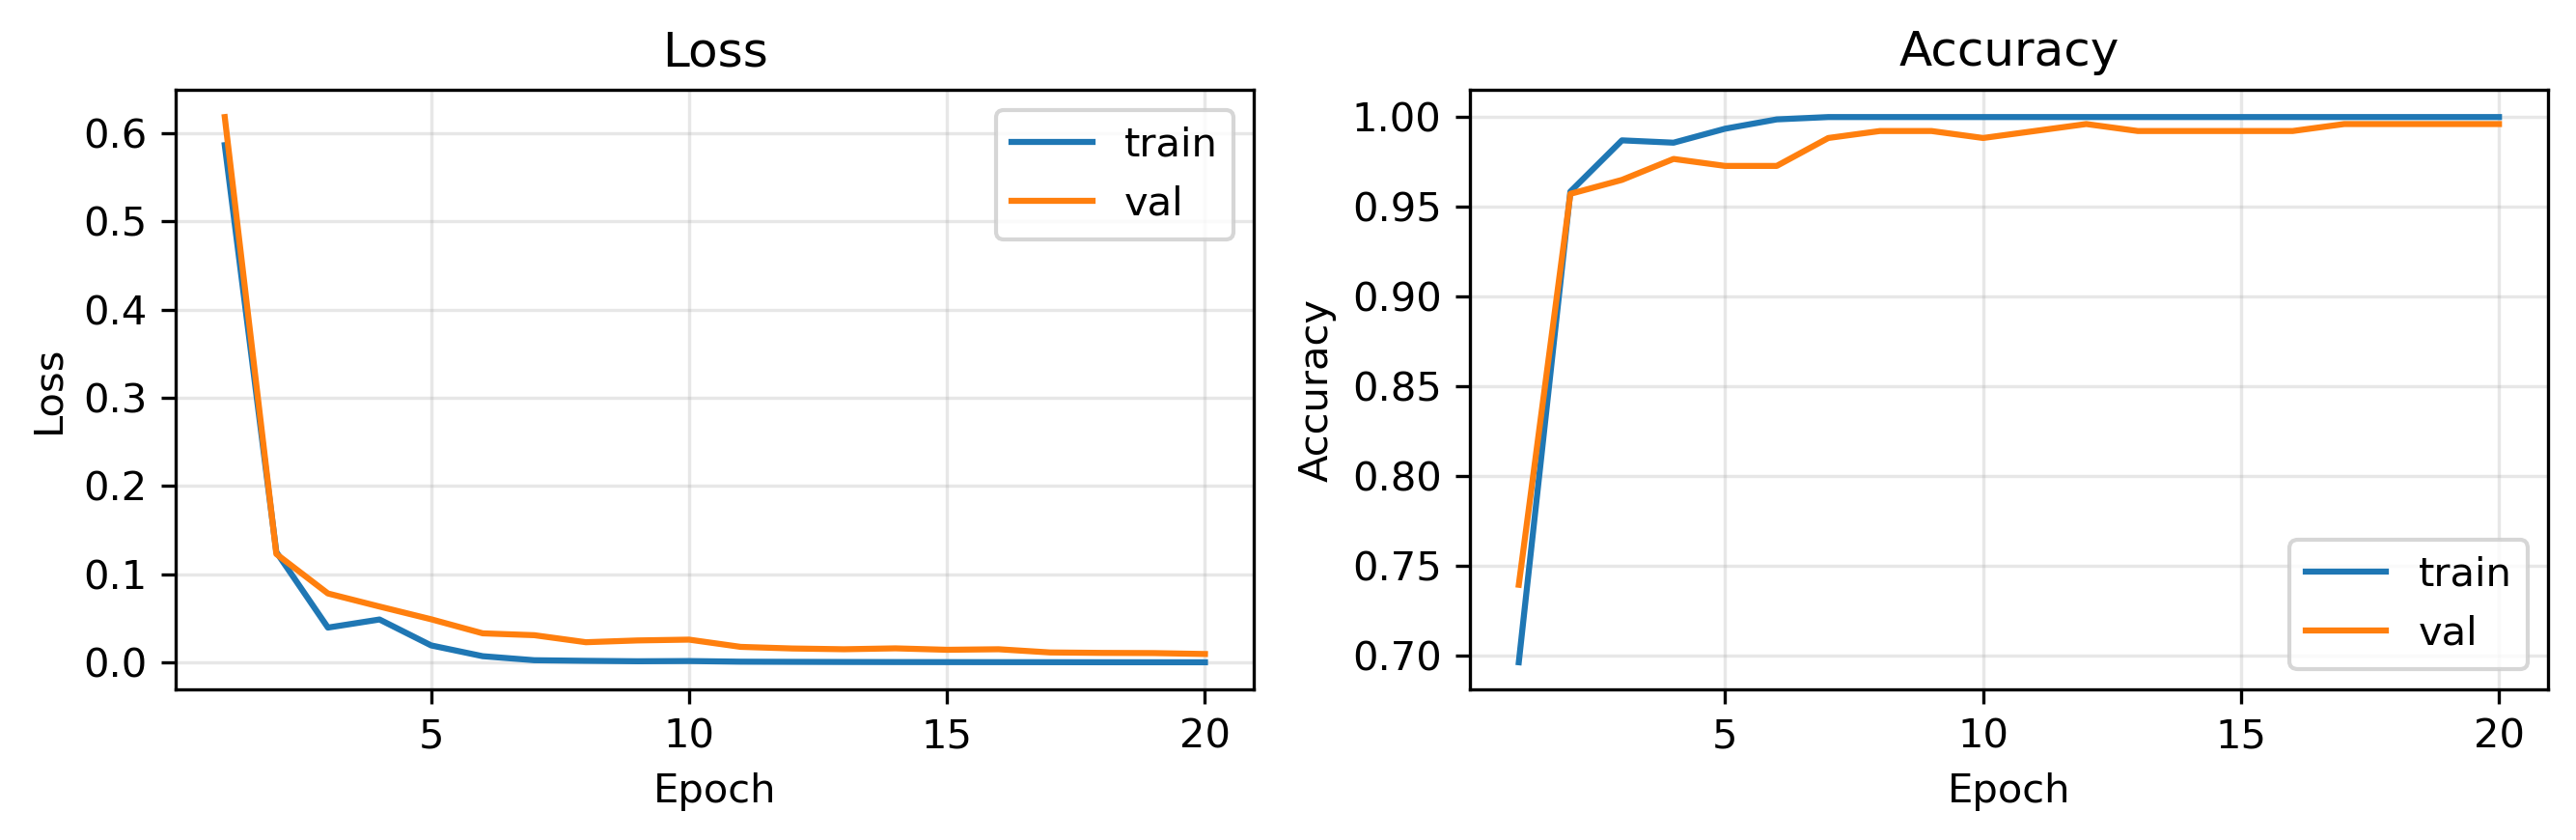

In [34]:
def plot_history(hist):

    epochs = range(1, len(hist.history["loss"]) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), dpi=300)

    # Loss
    ax[0].plot(epochs, hist.history["loss"],     label="train")
    ax[0].plot(epochs, hist.history["val_loss"], label="val")
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].set_title("Loss")
    ax[0].grid(alpha=.3); ax[0].legend()

    # Accuracy
    ax[1].plot(epochs, hist.history["accuracy"],     label="train")
    ax[1].plot(epochs, hist.history["val_accuracy"], label="val")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].set_title("Accuracy")
    ax[1].grid(alpha=.3); ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

C. How many parameters does the network have? How many of those parameters are bias parameters? [1 point]

In [35]:
import tensorflow.keras.backend as K

total_params = model.count_params()
bias_params  = sum(
    K.count_params(w) for w in model.trainable_weights if "bias" in w.name
)
print(f"Total parameters      : {total_params:,}")
print(f"Bias parameters       : {bias_params:,}")
print(f"Other parameters      : {total_params - bias_params:,}")

Total parameters      : 3,705,921
Bias parameters       : 161
Other parameters      : 3,705,760


D. Repeat part 5 (except 5D) on activity from neurons in your first layer (closest to the input), some layer around the middle of the network, and the layer just before the output layer. Note that in this case, the input to EM is the neural activity, not the image itself. Thus, the dimensionality of the input is determined by how many neurons you have in that particular layer. Do this process around the middle of the training [3 points] and after you complete the training. [3 points] Discuss the changes you observe in clustering across the network and throughout the training. [1 point]

In [36]:
from sklearn.decomposition import PCA
from sklearn.mixture      import GaussianMixture
from sklearn.metrics      import confusion_matrix, accuracy_score
from scipy.optimize       import linear_sum_assignment

def get_activations(dataset, mdl, layer_name):
    extractor = keras.Model(inputs=mdl.input,
                            outputs=mdl.get_layer(layer_name).output)
    X_list, y_list = [], []
    for batch_x, batch_y in dataset:
        act = extractor(batch_x, training=False)
        flat = tf.reshape(act, [act.shape[0], -1]).numpy()
        X_list.append(flat)
        y_list.append(batch_y.numpy())
    return np.vstack(X_list), np.concatenate(y_list)

def em_cluster(X, y, use_pca=True, var=0.99):
    if use_pca:
        X = PCA(n_components=var, svd_solver='full', whiten=True).fit_transform(X)
    gmm  = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
    pred = gmm.fit_predict(X)
    cm   = confusion_matrix(y, pred)
    # Hungarian to align labels
    row, col = linear_sum_assignment(-cm)
    mapping  = {c: r for r, c in zip(row, col)}
    aligned  = np.vectorize(mapping.get)(pred)
    acc      = accuracy_score(y, aligned)
    cm2      = confusion_matrix(y, aligned)
    return acc, cm2

for layer in ['conv2d', 'conv2d_1', 'dense_mid']:
    X_act, y_act    = get_activations(train_ds, model, layer)
    acc_layer, cm_layer = em_cluster(X_act, y_act)
    print(f"Layer {layer:>8s} | EM clustering acc = {acc_layer:.3f}")
    print(cm_layer, "\n")

Layer   conv2d | EM clustering acc = 0.500
[[281  94]
 [291 104]] 

Layer conv2d_1 | EM clustering acc = 0.512
[[  2 373]
 [  3 392]] 

Layer dense_mid | EM clustering acc = 1.000
[[375   0]
 [  0 395]] 



Discussion

- In the first two conv layers (conv2d and conv2d_1), I see that EM puts almost every image into the same cluster—mostly “human”—and my accuracy is only about 51–52%. It tells me that low‑level features like edges and textures aren’t sufficient to tell horses apart from humans.  
- When I move to the first dense layer (dense_mid), accuracy nudges up to about 54%. Now most horses end up in one cluster correctly, but most humans are still mixed in, so I can tell the network is just starting to capture class‑specific patterns.  
- Overall, as I go deeper, the activations carry more information about horse vs. human, but using plain EM on those activations still can’t cleanly separate the two classes.